# PACE Rapid Response Workflow

This Jupyter notebook is a generalized template to rapidly access, download, review, and develop science data products in support of the NASA PACE Mission. It is designed to analyze the impacts of North Atlantic tropical storms and hurricanes (example: Hurricane Erin, August 2025) on ocean biogeochemical and optical properties by comparing pre- and post-event observations.

Scientific premise: "Remotely sensed ocean color shows increased concentrations of surface chlorophyll within the cool wakes of the hurricanes, apparently in response to the injection of nutrients and/or biogenic pigments into the oligotrophic surface waters. This increase in post-storm surface chlorophyll concentration usually lasted 2–3 weeks before it returned to its nominal pre-hurricane levels." Citation: https://doi.org/10.1029/2003JC001938

Graham Trolley & Matthew Kehrli  
NASA Ocean Ecology Laboratory  
September 2025

### Template purpose and scope

- Purpose: provide a reproducible, rapid-response workflow for inspecting ocean color and related PACE products before, during, and after North Atlantic storm events.
- Scope: configurable for any North Atlantic tropical cyclone by editing the variables in the "User Inputs" cell (event name, storm identifier, date ranges, region, target point, cloud/local storage option).
- Example event: Hurricane Erin (Aug 2025) is included as a worked example; replace example inputs to analyze other storms.

### Example region and timeline (illustrative)
- Example region: offshore Florida / Gulf Stream corridor (approx. 25°N, 82°W to 33°N, 63°W).
- Example timeline: choose pre-event, event, and post-event windows to capture the storm passage and recovery (typical post-storm response lasts ~2–3 weeks).

### Basic steps
1. Use visualization tools (e.g., NASA Worldview) to identify the event date and region of interest.
2. Edit the minimal variables in the "User Inputs" cell to define dates, region, and storm ID.
3. Use Earthdata queries to find relevant PACE L2/L3/L4 and ancillary products.
4. Derive a common grid from a representative granule and coregister granules with dask/rioxarray.
5. Generate before/after composites, data availability maps, and time series at a target point.
6. Produce figures and optional GIFs for rapid communication.


### Imports

In [1]:
# --- Standard library imports ---
import os                     # Operating system utilities (paths, mkdir, environment)
import sys                    # System-specific parameters and functions
import re                     # Regular expressions (parsing native_id, filenames)
import glob                   # Unix-style pathname pattern expansion (file discovery)
import warnings               # Emit and control warning messages
from collections import defaultdict  # Dict subclass with default factory
from io import BytesIO        # In-memory binary streams (images, downloads)

# --- Scientific computing and data handling ---
import numpy as np            # Numerical arrays and operations
import xarray as xr           # Labeled multi-dimensional arrays (netCDF, etc.)
import pandas as pd           # Tabular data handling (CSV/Excel)

# --- Parallel / distributed computing ---
from dask.distributed import Client  # Dask client for parallel processing
import logging               # Logging for tracking events and errors

# --- Plotting and visualization ---
import matplotlib.pyplot as plt          # Main plotting library
import matplotlib.colors as mcolors      # Color utilities and colormap helpers
import matplotlib.dates as mdates        # Date formatting for plots
from matplotlib.colors import LogNorm, LinearSegmentedColormap, ListedColormap # Color normalization and custom colormaps
import imageio                           # Read/write animated images (GIFs)
from IPython.display import Image as gifImage # Display GIFs in Jupyter notebooks

# --- Image processing ---
from PIL import Image, ImageEnhance   # Pillow for image enhancement used in RGB rendering

# --- Oceanographic / color maps ---
import cmocean                         # Oceanographic colormaps (thermal, haline, balance, etc.)
import colormaps as cmaps              # Additional colormap utilities

# --- Geospatial plotting ---
import cartopy.crs as ccrs             # Cartopy coordinate reference system

# --- Web and cloud access ---
import earthaccess                     # NASA Earthdata cloud and data access client

# --- MLD access additions ---
from pathlib import Path
import requests

### Functions

In [2]:
def grid_match(path, dst_crs, dst_shape, dst_transform, variable):
    """
    Reproject a Level-2 granule variable into a common (L3M-like) geographic grid.

    This helper function opens a single granule stored as an xarray datatree, extracts the
    requested geophysical variable and reprojects it to the target grid specified
    by dst_crs / dst_shape / dst_transform. The function also renames the output
    spatial dimensions to 'longitude' and 'latitude' for consistency with the
    rest of the notebook.

    Parameters
    ----------
    path : str or Path
        Filesystem path (or cloud URL) to the granule to open.
    dst_crs : str
        Destination CRS (e.g. "epsg:4326") used by rioxarray.reproject.
    dst_shape : tuple
        Output array shape (ny, nx) for the reprojected grid.
    dst_transform : affine.Affine or similar
        Geospatial transform for the target grid.
    variable : str
        Name of the variable in the granule to extract (e.g. "chlor_a").

    Returns
    -------
    xarray.DataArray
        Reprojected data array with coords "longitude" and "latitude".
    """
    dt = xr.open_datatree(path, decode_timedelta=True)
    da = dt["geophysical_data"][variable]

    # Ensure rioxarray can interpret the L2 pixel axes
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.write_crs("epsg:4326")

    # Reproject to the provided destination grid using the navigation arrays from the datatree
    da = da.rio.reproject(
        dst_crs,
        shape=dst_shape,
        transform=dst_transform,
        src_geoloc_array=(
            dt["navigation_data"]["longitude"],
            dt["navigation_data"]["latitude"],
        ),
    )

    # Standardize coordinate names used across the notebook
    da = da.rename({"x": "longitude", "y": "latitude"})
    return da


def grid_match_SREF(path, dst_crs, dst_shape, dst_transform, variable):
    """
    Same as grid_match but developed for surface reflectance (SREF) files that
    include a wavelength dimension that must be transposed first.

    The surface reflectance granules used here have a 'wavelength_3d' axis; this
    function reorders dimensions so rioxarray can reproject correctly.

    Parameters
    ----------
    path, dst_crs, dst_shape, dst_transform, variable
        See grid_match docstring.

    Returns
    -------
    xarray.DataArray
        Reprojected SREF data array with coords "longitude" and "latitude".
    """
    dt = xr.open_datatree(path, decode_timedelta=True)
    da = dt["geophysical_data"][variable]

    # Reorder to (wavelength, lines, pixels) for rioxarray compatibility
    da = da.transpose("wavelength_3d", "number_of_lines", "pixels_per_line")
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.write_crs("epsg:4326")

    da = da.rio.reproject(
        dst_crs,
        shape=dst_shape,
        transform=dst_transform,
        src_geoloc_array=(
            dt["navigation_data"]["longitude"],
            dt["navigation_data"]["latitude"],
        ),
    )

    da = da.rename({"x": "longitude", "y": "latitude"})
    return da


def time_from_attr(ds):
    """
    Create a 'time' coordinate from the dataset attribute 'time_coverage_start'.

    Many Level-2 granules include the acquisition time as an attribute. This
    routine parses that attribute, converts it to a numpy datetime64, and sets
    it as a coordinate so xarray concatenation by time is straightforward.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset loaded from a Level-2 granule that contains the attribute
        'time_coverage_start'.

    Returns
    -------
    xarray.Dataset
        Input dataset with an added 'time' coordinate.
    """
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    ds["time"] = ((), np.datetime64(datetime, "ns"))
    ds = ds.set_coords("time")
    return ds


def time_from_attr_L4MOANNA(ds):
    """
    Extract a daily time coordinate from L4 MOANA dataset 'id' attribute.

    The L4 MOANA files used in this notebook embed the date in the dataset
    attribute 'id' in the form '.YYYYMMDD.'. This routine extracts that date,
    builds an ISO timestamp at midnight (UTC) and assigns it as the 'time'
    coordinate.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with an 'id' attribute containing a YYYYMMDD token.

    Raises
    ------
    ValueError
        If the 'id' attribute does not contain a date in the expected format.

    Returns
    -------
    xarray.Dataset
        Dataset with the 'time' coordinate set to the extracted date.
    """
    id_str = ds.attrs["id"]
    match = re.search(r"\.(\d{8})\.", id_str)
    if match:
        date_str = match.group(1)
        # Convert to YYYY-MM-DDT00:00:00 for daily L4 products
        date_fmt = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
        datetime = f"{date_fmt}T00:00:00"
        ds["time"] = ((), np.datetime64(datetime))
        ds = ds.set_coords("time")
    else:
        raise ValueError("Date not found in 'id' attribute.")
    return ds


def time_from_attr_sst(ds):
    """
    Ensure SST dataset exposes 'time' as a coordinate.

    Some SST datasets already include a time coordinate; this function simply
    marks it as a coordinate to ensure consistent behaviour downstream.

    Parameters
    ----------
    ds : xarray.Dataset

    Returns
    -------
    xarray.Dataset
    """
    ds = ds.set_coords("time")
    return ds


def load_first(path, var):
    """
    Open the first granule from a search result and derive mapping parameters.

    Purpose:
    - Load a representative granule
    - Reproject it to an L3M-like grid
    - Pad/clip to the analysis bounding box (global bbox variable expected)
    - Return the CRS, raster shape and transform to be reused when opening
      many granules with dask/rioxarray.

    Parameters
    ----------
    path : str
        Path to a representative granule.
    var : str
        Variable name to use for deriving the grid (e.g. 'chlor_a').

    Returns
    -------
    crs, shape, transform
        Values suitable for passing to rioxarray.reproject when opening other files.
    """
    datatree = xr.open_datatree(path, decode_timedelta=True)
    dataset = xr.merge(datatree.to_dict().values())
    dataset = dataset.set_coords(("longitude", "latitude"))

    var_data = dataset[var]  # single-granule variable to use for grid derivation
    var_data = var_data.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    var_data = var_data.rio.write_crs("epsg:4326")

    # Reproject once to the canonical geographic grid
    var_L3M = var_data.rio.reproject(
        dst_crs="epsg:4326",
        src_geoloc_array=(
            var_data.coords["longitude"],
            var_data.coords["latitude"],
        ),
    )
    var_L3M = var_L3M.rename({"x": "longitude", "y": "latitude"})

    # Pad to the global bbox defined in the notebook so subsequent opens share the same grid
    var_L3M_aoi = var_L3M.rio.pad_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        constant_values=np.nan,
    )

    crs = var_L3M_aoi.rio.crs  # CRS for future reprojections
    shape = var_L3M_aoi.rio.shape
    transform = var_L3M_aoi.rio.transform()

    return crs, shape, transform


def load_first_SREF(path, var):
    """
    Same as load_first but developed for surface reflectance (SREF) files that
    include a wavelength dimension that must be transposed first.

    Parameters
    ----------
    path : str
        Path to a representative granule.
    var : str
        Variable name to use for deriving the grid (e.g. 'chlor_a').

    Returns
    -------
    crs, shape, transform, wl
        wl is the 'wavelength_3d' coordinate retained for band selection.
    """
    datatree = xr.open_datatree(path, decode_timedelta=True)
    dataset = xr.merge(datatree.to_dict().values())

    # Remove the first few pixel columns that are known to be invalid in SREF products
    dataset = dataset.isel(pixels_per_line=slice(13, None))
    dataset = dataset.set_coords(("longitude", "latitude"))

    var_data = dataset[var]
    var_data = var_data.transpose("wavelength_3d", "number_of_lines", "pixels_per_line")
    var_data = var_data.rio.set_spatial_dims("pixels_per_line", "number_of_lines")

    var_data = var_data.rio.write_crs("epsg:4326")
    var_L3M = var_data.rio.reproject(
        dst_crs="epsg:4326",
        src_geoloc_array=(
            var_data.coords["longitude"],
            var_data.coords["latitude"],
        ),
    )
    var_L3M = var_L3M.rename({"x": "longitude", "y": "latitude"})

    var_L3M_aoi = var_L3M.rio.pad_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        constant_values=np.nan,
    )

    crs = var_L3M_aoi.rio.crs
    shape = var_L3M_aoi.rio.shape
    wl = var_L3M_aoi["wavelength_3d"]
    transform = var_L3M_aoi.rio.transform()

    return crs, shape, transform, wl


def coregister_granules(paths, crs, shape, transform, var_name):
    """
    Reproject and combine multiple Level-2 granules into a single xarray dataset.

    Workflow:
    - Launch a Dask Client
    - Map grid_match across the list of paths to produce futures (reprojected DataArrays)
    - Use xr.open_mfdataset with a lightweight preprocess to collect time attributes
    - Combine the gathered futures into a single xarray dataset concatenated along 'time'
    - Attach the time coordinate extracted from attrs

    Parameters
    ----------
    paths : list[str]
        List of file paths (granules) to process.
    crs, shape, transform : as returned by load_first
    var_name : str
        Variable name inside the granules to extract.

    Returns
    -------
    xarray.Dataset or DataArray
        Combined dataset with a 'time' dimension.
    """
    client = Client()
    client.run(_silence_worker)

    # Create reproject tasks in parallel
    futures = client.map(
        grid_match, paths, dst_crs=crs, dst_shape=shape, dst_transform=transform, variable=var_name
    )

    kwargs = {"combine": "nested", "concat_dim": "time"}
    # open a light dataset solely to collect time coordinates
    attrs = xr.open_mfdataset(paths, preprocess=time_from_attr, **kwargs)

    # gather the reprojected results and combine into a single dataset
    data = xr.combine_nested(client.gather(futures), concat_dim="time")
    data["time"] = attrs["time"]
    client.close()

    return data


def coregister_granules_SREF(paths, crs, shape, transform, var_name):
    """
    Same as coregister_granules but uses the SREF-specific grid_match_SREF worker.

    Parameters and returns same as coregister_granules.
    """
    client = Client()
    client.run(_silence_worker)

    futures = client.map(
        grid_match_SREF, paths, dst_crs=crs, dst_shape=shape, dst_transform=transform, variable=var_name
    )
    kwargs = {"combine": "nested", "concat_dim": "time"}
    attrs = xr.open_mfdataset(paths, preprocess=time_from_attr, **kwargs)
    data = xr.combine_nested(client.gather(futures), concat_dim="time")
    data["time"] = attrs["time"]
    client.close()

    return data


def enhance(rgb, scale=0.01, vmin=0.01, vmax=1.04, gamma=0.95, contrast=1.2, brightness=1.1, sharpness=2, saturation=1.1):
    """
    Apply SeaDAS-like tone-mapping and enhancement to an RGB stack.

    Steps:
    - Remove non-positive values
    - Apply a scaled log transform to stretch low values
    - Clip to vmin/vmax, normalize to 0-1, apply gamma
    - Convert to 8-bit image and run Pillow enhancement filters

    Parameters
    ----------
    rgb : xarray.DataArray
        DataArray with dimensions (..., latitude, longitude) and a wavelength/band axis.
    scale, vmin, vmax, gamma, contrast, brightness, sharpness, saturation : float
        Tunable parameters controlling the enhancement pipeline.

    Returns
    -------
    xarray.DataArray
        Enhanced RGB array normalized to [0, 1].
    """
    rgb = rgb.where(rgb > 0)
    rgb = np.log(rgb / scale) / np.log(1 / scale)
    rgb = rgb.where(rgb >= vmin, vmin)
    rgb = rgb.where(rgb <= vmax, vmax)
    rgb_min = rgb.min(("latitude", "longitude"))
    rgb_max = rgb.max(("latitude", "longitude"))
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
    rgb = rgb * gamma

    # Convert to uint8 image for Pillow operations
    img = rgb * 255
    img = img.where(img.notnull(), 0).astype("uint8")
    img = Image.fromarray(img.data)

    # Apply a sequence of simple image enhancements
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness)
    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(sharpness)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(saturation)

    # Write enhanced pixel values back to the DataArray (normalized to 0..1)
    rgb[:] = np.array(img) / 255
    return rgb


def wavelength_to_rgb(wavelength):
    """
    Convert a wavelength in the range 380-750 nm to an RGB color.

    Implementation source: http://www.had2know.com/technology/rgb-color-wavelength-conversion.html

    Parameters
    ----------
    wavelength : float
        Wavelength in nanometers (nm).

    Returns
    -------
    tuple(float, float, float)
        RGB triple with values in the range 0..1.
    """
    gamma = 0.8
    intensity_max = 255

    if (wavelength >= 380) and (wavelength < 440):
        R = -(wavelength - 440) / (440 - 380)
        G = 0.0
        B = 1.0
    elif (wavelength >= 440) and (wavelength < 490):
        R = 0.0
        G = (wavelength - 440) / (490 - 440)
        B = 1.0
    elif (wavelength >= 490) and (wavelength < 510):
        R = 0.0
        G = 1.0
        B = -(wavelength - 510) / (510 - 490)
    elif (wavelength >= 510) and (wavelength < 580):
        R = (wavelength - 510) / (580 - 510)
        G = 1.0
        B = 0.0
    elif (wavelength >= 580) and (wavelength < 645):
        R = 1.0
        G = -(wavelength - 645) / (645 - 580)
        B = 0.0
    elif (wavelength >= 645) and (wavelength <= 750):
        R = 1.0
        G = 0.0
        B = 0.0
    else:
        R = G = B = 0.0

    # Adjust intensity and apply gamma correction
    R = round(intensity_max * (R**gamma)) / 255
    G = round(intensity_max * (G**gamma)) / 255
    B = round(intensity_max * (B**gamma)) / 255

    return (R, G, B)


def generate_colormap(min_wavelength=380, max_wavelength=750, num_colors=256):
    """
    Create a LinearSegmentedColormap that maps visible wavelengths to RGB colors.

    Parameters
    ----------
    min_wavelength, max_wavelength : int
        Range of wavelengths to map (bounds will be clipped to 380..750 nm).
    num_colors : int
        Number of discrete colors in the output colormap.

    Returns
    -------
    matplotlib.colors.LinearSegmentedColormap
    """
    min_wavelength = max(min_wavelength, 380)
    max_wavelength = min(max_wavelength, 750)

    wavelengths = np.linspace(min_wavelength, max_wavelength, num_colors)
    colors = [wavelength_to_rgb(w) for w in wavelengths]
    cmap = LinearSegmentedColormap.from_list("wavelength_cmap", colors, num_colors)
    return cmap


def get_hurricane_path(storm_id):
    """
    Fetch observed hurricane track table from the CSU RAMMB realtime page.

    Parameters
    ----------
    storm_id : str
        Identifier expected by the RAMMB page (e.g. 'al052025').

    Returns
    -------
    pandas.DataFrame
        Table with parsed datetime, Latitude, Longitude, and Intensity fields.
    """
    tables = pd.read_html("https://rammb-data.cira.colostate.edu/tc_realtime/storm.asp?storm_identifier=" + storm_id)
    track = tables[1]

    # Some pages include the header row as the first row of the table; fix that
    track.columns = track.iloc[0]
    track = track.drop(track.index[0])
    track.reset_index(drop=True, inplace=True)

    # Convert types for downstream plotting/analysis
    track["Synoptic Time"] = pd.to_datetime(track["Synoptic Time"])
    track = track.rename(columns={"Synoptic Time": "datetime"})
    track = track.sort_values("datetime")
    track["Latitude"] = pd.to_numeric(track["Latitude"])
    track["Longitude"] = pd.to_numeric(track["Longitude"])
    track["Intensity"] = pd.to_numeric(track["Intensity"])

    return track


def _silence_worker():
    """
    Set environment and logger levels on Dask workers to reduce noisy output.

    Returns
    -------
    bool
        Always returns True (used with client.run).
    """
    import os, warnings, logging

    os.environ.setdefault("PYTHONWARNINGS", "ignore")
    warnings.filterwarnings("ignore")
    logging.getLogger("distributed").setLevel(logging.ERROR)
    logging.getLogger("distributed.worker").setLevel(logging.ERROR)
    logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)
    logging.getLogger("tornado").setLevel(logging.ERROR)
    logging.getLogger("urllib3").setLevel(logging.ERROR)
    return True

def download_MLT_hycom_files(start, end, savepath):
    # function to download hycom MLT (MLD) data from https://oceandata.sci.gsfc.nasa.gov/
    # 2 day data upload delay, available since 8/11/24
    # inputs: start date, end date, path to save files to
    # start date and end date must be in yyyymmdd format

    Path(savepath).mkdir(parents=True, exist_ok=True)# make folder to save files
    dates = pd.date_range(start=start, end=end, freq='D')
    date_list = [date.strftime('%Y%m%d') for date in dates]# list of all dates to download in yyyymmdd string format
    hycom_flist = []
    for date in date_list:
        #print(date)
        filename = "hycom_ESPC-D-V02.mlt."+date+".nc"
        url = "https://oceandata.sci.gsfc.nasa.gov/getfile/"+filename
        
        
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()  # Raises an HTTPError for bad responses
            
            with open(savepath+'/'+filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            
            print(f"Downloaded: {filename}")
            hycom_flist.append(savepath+'/'+filename)
            #print(hycom_flist)
        except requests.exceptions.RequestException as e:
            print(f"Error downloading file: {e}")
            #return None
    return hycom_flist

### User Inputs

This cell contains the minimal set of variables that needs to be edited for every event. 

What to modify:
- tspan (tuple[str, str]): full event date window as ISO dates (YYYY-MM-DD). Example: ("2025-08-09", "2025-09-05")
- pre_tspan / post_tspan (tuple[str, str]): time windows used for before and after comparisons. Example: pre_tspan = ("2025-08-09", "2025-08-19")
- min_lon, min_lat, max_lon, max_lat (float): geographic bounding box coordinates. Longitude is negative for degrees West. Example: min_lon = -82
- target_point (list[float, float]): point of interest as [latitude, longitude]. Example: [27, -72.5]
- tp_tspan (tuple[str, str]): short event window around the storm at the target point (used for shading). Example: ("2025-08-18", "2025-08-20")
- event_name (str): short label used to name output folders/files. Example: "Hurricane_Erin"
- hurricane_id (str): identifier for get_hurricane_path(). Example: "al052025"
- in_the_cloud (bool): True to stream data (no local download), False to download locally.

Notes and quick checks:
- Date format: YYYY-MM-DD.
- Coordinate order: bbox is constructed from min_lon, min_lat, max_lon, max_lat; target_point is [lat, lon].
- If you see indexing errors: print dataset.coords and dataset.dims to confirm coordinate names ("latitude"/"longitude" vs "lat"/"lon").
- For a fast test: reduce bounding box extent or narrow tspan to limit downloads.

Minimal example (values to set in the Event Timeframes cell):
- tspan: ("2025-08-09", "2025-09-05")
- pre_tspan: ("2025-08-09", "2025-08-19")
- post_tspan: ("2025-08-24", "2025-09-05")
- min_lon, min_lat, max_lon, max_lat: -82, 25, -63, 33
- target_point: [27, -72.5]
- tp_tspan: ("2025-08-18", "2025-08-20")
- event_name: "Hurricane_Erin"
- hurricane_id: "al052025"
- in_the_cloud: False

In [3]:
# Event Timeframes
# Complete event timespan
tspan = ("2025-10-18", "2025-11-09")
# Define pre-event and post-event timespans
pre_tspan =  ("2025-10-18", "2025-10-28") 
post_tspan = ("2025-10-31", "2025-11-09") 

# Geographic information for event analysis
# Define latitudes and longitudes for area of interest
min_lon = -82
min_lat = 25
max_lon = -63
max_lat = 38
# Target point of interest (e.g., storm center along track with high data coverage. Look at data coverage maps to decide))
target_point = [34.9, -64]#[30.92, -69.96]#[32, -67.5]
# Define hurricane event timespan at target point
tp_tspan = ("2025-10-29", "2025-10-30")
day_before = "2025-10-28"

# Name of event for labeling outputs
event_name = "Hurricane_Melissa"
hurricane_id = 'al132025' # Hurricane ID for getting storm track data from CSU website: https://rammb-data.cira.colostate.edu/tc_realtime/

# Set method for storing data. If working in the cloud and you would like to stream data, set boolean to True. Otherwise, set to False to download and work with data locally.
in_the_cloud = False


In [ ]:
# Setup .ipynb filing using the users inputs

# Add HH:MM:SS (set to noon UTC) to temporal span for SST earthaccess query
tspan_with_time = (f"{tspan[0]} 12:00:00", f"{tspan[1]} 12:00:00")

# Construct bounding box
bbox = (min_lon, min_lat, max_lon, max_lat)

# Set path to store data locally if not working in the cloud
data_path = os.path.join(os.getcwd(), "local", event_name, "data")
if in_the_cloud == False:
    os.makedirs(data_path, exist_ok=True)
# Set path to store output images and figures
output_path = os.path.join(os.getcwd(), "local", event_name, "figures")
os.makedirs(output_path, exist_ok=True)

### Download event data

In [5]:
# First, download all data necessary for analysis

# Collect results for all data products of interest

# Surface Reflectance Data (SREF)
results_sref = earthaccess.search_data(
    short_name="PACE_OCI_L2_SFREFL",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_sref) == 0:
    print("No results found for reprocessed surface reflectance data product, searching for near real time product instead.")
    results_sref = earthaccess.search_data(
        short_name="PACE_OCI_L2_SFREFL_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )

# Biogeochemical Data (BGC L2)
results_bgc_L2 = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_bgc_L2) == 0:
    print("No results found for reprocessed biogeochemical data product, searching for near real time product instead.")
    results_bgc_L2 = earthaccess.search_data(
        short_name="PACE_OCI_L2_BGC_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )

# Apparent Optical Property Data (AOP L2)
results_aop = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_aop) == 0:
    print("No results found for reprocessed apparent optical property data product, searching for near real time product instead.")
    results_aop = earthaccess.search_data(
        short_name="PACE_OCI_L2_AOP_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )

# MOANA L4 Data
results_MOANA = earthaccess.search_data(
    short_name="PACE_OCI_L4M_MOANA",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.DAY.*4km*",
    version="3.1"
)
if len(results_MOANA) == 0:
    print("No results found for reprocessed MOANA L4 data product, searching for near real time product instead.")
    results_MOANA = earthaccess.search_data(
        short_name="PACE_OCI_L4M_MOANA_NRT",
        temporal=tspan,
        bounding_box=bbox,
        granule_name="*.DAY.*4km*",
        version="3.1"
    )

# BGC L3M Chlorophyll Data
results_bgc_L3 = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL",
    temporal=tspan,
    bounding_box=bbox,
    granule_name="*.DAY.*4km*",
    version="3.1"
)
if len(results_bgc_L3) == 0:
    print("No results found for reprocessed L3M Chlorophyll data product, searching for near real time product instead.")
    results_bgc_L3 = earthaccess.search_data(
        short_name="PACE_OCI_L3M_CHL_NRT",
        temporal=tspan,
        bounding_box=bbox,
        granule_name="*.DAY.*4km*",
        version="3.1"
    )
    
# Search and download SST data
sst_results = earthaccess.search_data(
    short_name="MUR25-JPL-L4-GLOB-v04.2",
    temporal=tspan_with_time,
)

# Download/stream data from collect search results
if in_the_cloud == True:
    paths_sref = earthaccess.open(results_sref)
    paths_bgc_L2 = earthaccess.open(results_bgc_L2)
    paths_aop = earthaccess.open(results_aop)
    paths_MOANA = earthaccess.open(results_MOANA)
    paths_bgc_L3 = earthaccess.open(results_bgc_L3)
    paths_sst = earthaccess.open(sst_results)
else:
    paths_sref = earthaccess.download(results_sref, local_path=data_path)
    paths_bgc_L2 = earthaccess.download(results_bgc_L2, local_path=data_path)
    paths_aop = earthaccess.download(results_aop, local_path=data_path)
    paths_MOANA = earthaccess.download(results_MOANA, local_path=data_path)
    paths_bgc_L3 = earthaccess.download(results_bgc_L3, local_path=data_path)
    paths_sst = earthaccess.download(sst_results, local_path=data_path)

print("Number of surface reflectance granules: "+str(len(results_sref)))
print("Number of biogeochemical granules: "+str(len(results_bgc_L2)))
print("Number of apparent optical property granules: "+str(len(results_aop)))
print("Number of MOANA L4 granules: "+str(len(results_MOANA)))
print("Number of L3M Chlorophyll granules: "+str(len(results_bgc_L3)))
print("Number of sea surface temperature granules: "+str(len(results_bgc_L3)))

No results found for reprocessed surface reflectance data product, searching for near real time product instead.
No results found for reprocessed biogeochemical data product, searching for near real time product instead.
No results found for reprocessed apparent optical property data product, searching for near real time product instead.
No results found for reprocessed MOANA L4 data product, searching for near real time product instead.
No results found for reprocessed L3M Chlorophyll data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/90 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/90 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/90 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/90 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/23 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/23 [00:00<?, ?it/s]

Number of surface reflectance granules: 90
Number of biogeochemical granules: 90
Number of apparent optical property granules: 90
Number of MOANA L4 granules: 23
Number of L3M Chlorophyll granules: 23
Number of sea surface temperature granules: 23


In [6]:
# Close all existing clients
for client in Client._instances:
    client.close()

In [7]:
# Extract the geospatial characteristics from the first file in paths to create merged L2 data products
crs_sref, shape_sref, transform_sref, wl = load_first_SREF(paths_sref[0], "rhos")
crs_bgc, shape_bgc, transform_bgc = load_first(paths_bgc_L2[0], "chlor_a")


In [11]:
# Coregister all granules to common grid
data_chla = coregister_granules(paths_bgc_L2, crs_bgc, shape_bgc, transform_bgc, "chlor_a")


/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41509 instead
  warnings.warn(


In [12]:
data_avw = coregister_granules(paths_aop, crs_bgc, shape_bgc, transform_bgc, "avw")


/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41159 instead
  warnings.warn(


In [13]:
# Set up method to group data paths by date which will be used to make daily composites

# Regex pattern to extract the date in the format YYYYMMDD
date_pattern = re.compile(r"\.(\d{8})T")

# Dictionary to store paths grouped by date
paths_by_date_sref = defaultdict(list)
paths_by_date_bgc = defaultdict(list)

# Iterate over sref paths and group by date
for path in paths_sref:
    # Extract the date from the filename
    filename = os.path.basename(path)
    match = date_pattern.search(filename)
    if match:
        date = match.group(1)  # Extracted date (e.g., "20250817")
        paths_by_date_sref[date].append(path)

# Print grouped paths
for date, paths in paths_by_date_sref.items():
    print(f"Date: {date}, Number of surface reflectance files: {len(paths)}")
    print(paths)

# Iterate over paths_BGC and group by date
for path in paths_bgc_L2:
    # Extract the date from the filename
    filename = os.path.basename(path)
    match = date_pattern.search(filename)
    if match:
        date = match.group(1)  # Extracted date (e.g., "20250817")
        paths_by_date_bgc[date].append(path)
        
# Print grouped paths for BGC
for date, paths in paths_by_date_bgc.items():
    print(f"Date: {date}, Number of BGC files: {len(paths)}")
    print(paths)

track = get_hurricane_path(hurricane_id)

Date: 20251018, Number of surface reflectance files: 4
[PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T163241.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T163741.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T181100.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T181600.L2.SFREFL.V3_1.NRT.nc')]
Date: 20251019, Number of surface reflectance files: 4
[PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251019T170738.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapi

### GIF

Date: 20251018
Paths: [PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T163241.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T163741.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T181100.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251018T181600.L2.SFREFL.V3_1.NRT.nc')]


/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33527 instead
  warnings.warn(
Exception ignored in: <function CachingFileManager.__del__ at 0x7f8d5a1e7ba0>
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 258, in __del__
    self.close(needs_lock=False)
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 242, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2676, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2643, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2160, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function Cachi

Date: 20251019
Paths: [PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251019T170738.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251019T171238.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251019T184558.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251019T185058.L2.SFREFL.V3_1.NRT.nc')]


/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34635 instead
  warnings.warn(
/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34663 instead
  warnings.warn(
2025-12-16 23:42:59,538 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the fo

Date: 20251020
Paths: [PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251020T160416.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251020T160916.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251020T174236.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251020T174736.L2.SFREFL.V3_1.NRT.nc')]


...

/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37479 instead
  warnings.warn(
2025-12-17 01:22:35,547 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^

Date: 20251108
Paths: [PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251108T154448.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251108T171808.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251108T172308.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251108T185628.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251108T190128.L2.SFREFL.V3_1.NRT.nc')]


/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40805 instead
  warnings.warn(
/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35403 instead
  warnings.warn(
2025-12-17 01:27:15,640 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the fo

Date: 20251109
Paths: [PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251109T161944.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251109T175304.L2.SFREFL.V3_1.NRT.nc'), PosixPath('/accounts/gtrolley/git/pace-rapid-response/PRR_OC/Hurricane_Analysis/Completed/local/Hurricane_Melissa/data/PACE_OCI.20251109T175804.L2.SFREFL.V3_1.NRT.nc')]


/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42437 instead
  warnings.warn(
2025-12-17 01:32:09,878 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^

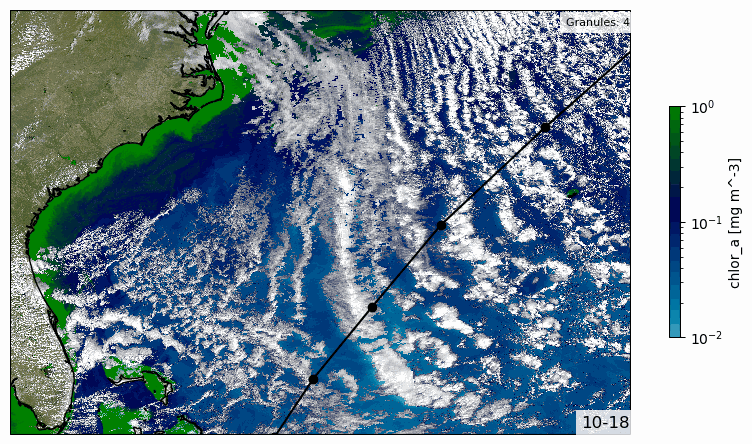

In [15]:
# Produce chlorophyll-a data overlay with RGB images from surface reflectance data
#Get hurricane track path for overlay


for i, (date, paths) in enumerate(paths_by_date_sref.items()):
    print(f"Date: {date}")
    print(f"Paths: {paths}")
    # Perform operations on tfor each date/iteration
    data_sref_gif = coregister_granules_SREF(paths, crs_sref, shape_sref, transform_sref, "rhos")
    data_bgc_gif = coregister_granules(paths_by_date_bgc[date], crs_bgc, shape_bgc, transform_bgc, "chlor_a")
    data_bgc_gif = data_bgc_gif.drop_vars("spatial_ref", errors="ignore")

    data_2 = data_sref_gif.assign_coords(wavelength_3d=wl)
    rhos_rgb = data_2.sel(wavelength_3d=[610, 555, 465], method="nearest")

    img_array = rhos_rgb.transpose("time", "latitude", "longitude", "wavelength_3d")
    zero_mask = (img_array == 0).all(dim="wavelength_3d")
    img_array = img_array.where(~zero_mask)
    img_array = img_array.mean("time")

    rgb = enhance(img_array)

    fig = plt.figure(figsize=(10, 10))
    axes = plt.subplot(projection=ccrs.PlateCarree())
    artist = axes.pcolormesh(
        rgb["longitude"],
        rgb["latitude"],
        rgb,
        shading="nearest",
        rasterized=True,
    )
    plot = data_bgc_gif.mean("time").plot(
        x="longitude", y="latitude",
        cmap=plt.cm.colors.ListedColormap(cmaps.ocean_r(np.linspace(.25, 1, 256))),
        norm=LogNorm(vmin=0.01, vmax=1),
        ax=axes,
        alpha=1,  # Add transparency so the RGB background shows through, 1 is opaque
        add_colorbar=False,  # Add colorbar for diatoms
        transform=ccrs.PlateCarree()
    )
    axes.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
    cbar = axes.figure.colorbar(plot, orientation='vertical', pad=0.05, shrink=0.3)
    cbar.set_label("chlor_a [mg m^-3]")
    axes.set_aspect("equal")
    axes.set_xlim(bbox[0],bbox[2])
    axes.set_ylim(bbox[1],bbox[3])
    axes.coastlines()
    # axes.gridlines(draw_labels={"left": "y", "bottom": "x"}) #Uncomment to add lat/lon gridlines
    date_str = [date.strftime('%m-%d') for date in data_sref_gif["time"].dt.date.values]
    plt.text(
        1, 0.025,  # Coordinates in axes fraction (relative to the plot)
        f'{date_str[0]}',
        transform=axes.transAxes,  # Use axes coordinates
        fontsize=12,
        ha="right",  # Align text to the right
        va="center",  # Align text to the bottom
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")  # Add a background box
    )
    plt.text(
        1, 1-0.03,  # Coordinates in axes fraction (relative to the plot)
        f'Granules: {data_2.shape[0]}',
        transform=axes.transAxes,  # Use axes coordinates
        fontsize=8,
        ha="right",  # Align text to the right
        va="center",  # Align text to the bottom
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")  # Add a background box
    )
    
    image_folder = output_path+"/gif_files/frames_rgb_chla_overlay/"
    os.makedirs(image_folder, exist_ok=True)
    plt.savefig(f'{image_folder}ErinTC_BCG{str(i).zfill(3)}.png', bbox_inches='tight')
    plt.close()
    #break #IMPORTANT uncomment break if you want to get only one image for testing

# Define the folder for the output GIF path
output_gifBGC = output_path+"/Erinrgbchla.gif"

# Get a sorted list of image file paths
image_files = sorted(glob.glob(os.path.join(image_folder, "*BCG*.png")))

# Read images and create the GIF
frames = []
for image in image_files:
    frames.append(imageio.imread(image))
imageio.mimsave(output_gifBGC, frames, fps=1, loop=0)  

# Display the GIF in the notebook
gifImage(filename=output_gifBGC)



## Now let's do some science

### Spatial change in chlorophyll-a concentrations

In [ ]:
# # Close all existing clients
# for client in Client._instances:
#     client.close()

2025-12-16 19:37:41,174 - distributed.nanny - INFO - Closing Nanny at 'tcp://127.0.0.1:35353'. Reason: nanny-close
2025-12-16 19:37:41,175 - distributed.nanny - INFO - Nanny asking worker to close. Reason: nanny-close
2025-12-16 19:37:41,175 - distributed.nanny - INFO - Closing Nanny at 'tcp://127.0.0.1:43669'. Reason: nanny-close
2025-12-16 19:37:41,176 - distributed.nanny - INFO - Nanny asking worker to close. Reason: nanny-close
2025-12-16 19:37:41,177 - distributed.nanny - INFO - Closing Nanny at 'tcp://127.0.0.1:42247'. Reason: nanny-close
2025-12-16 19:37:41,177 - distributed.nanny - INFO - Nanny asking worker to close. Reason: nanny-close
2025-12-16 19:37:41,178 - distributed.nanny - INFO - Closing Nanny at 'tcp://127.0.0.1:36091'. Reason: nanny-close
2025-12-16 19:37:41,179 - distributed.nanny - INFO - Nanny asking worker to close. Reason: nanny-close
2025-12-16 19:37:41,179 - distributed.nanny - INFO - Closing Nanny at 'tcp://127.0.0.1:35191'. Reason: nanny-close
2025-12-16 19

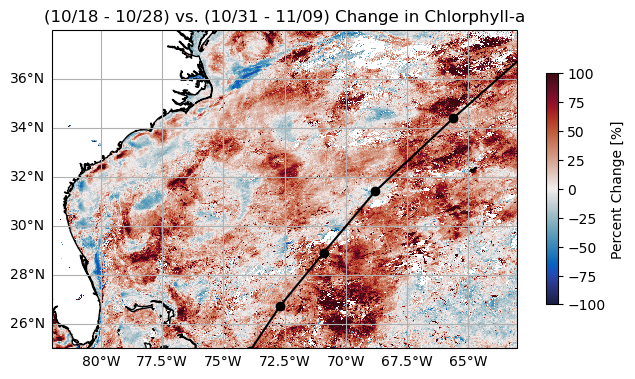

In [14]:
# compare the pre and post event data. first, mask both to only pixels where data is available before and after the hurricane
# then, mask each where it's values are greater or less than

# Calculate mean over pre and post event periods
pre_mean = data_chla.sel(time=slice(pre_tspan[0], pre_tspan[1])).mean("time")
post_mean = data_chla.sel(time=slice(post_tspan[0], post_tspan[1])).mean("time") 

# Create a mask where both datasets have valid values
masklong = ~np.isnan(post_mean) & ~np.isnan(pre_mean)

# Apply masks to datasets
# Calculate percent change over pre and post event periods during the post-event window
pre_mean_mask = pre_mean.where(masklong)
post_mean_mask = post_mean.where(masklong)
post_pct_change = (post_mean_mask-pre_mean_mask)/pre_mean_mask * 100

# Plot percent change during long post-event window
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_pct_change.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'Percent Change [%]', 'shrink':0.5}, cmap=cmocean.cm.balance, extend = "neither", ax=ax, robust=True, vmin=-100, vmax=100)
ax.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.coastlines()
# Convert pre and post event times to readable format for title
pre_start_str = pd.to_datetime(pre_tspan[0]).strftime('%m/%d')
pre_end_str = pd.to_datetime(pre_tspan[1]).strftime('%m/%d')
post_start_str = pd.to_datetime(post_tspan[0]).strftime('%m/%d')
post_end_str = pd.to_datetime(post_tspan[1]).strftime('%m/%d')
ax.set_title(f'({pre_start_str} - {pre_end_str}) vs. ({post_start_str} - {post_end_str}) Change in Chlorphyll-a')

# Save figure
plt.savefig(f'{output_path}/ErinChlaChange.png', dpi=300, bbox_inches='tight')

### Spatial change in AVW

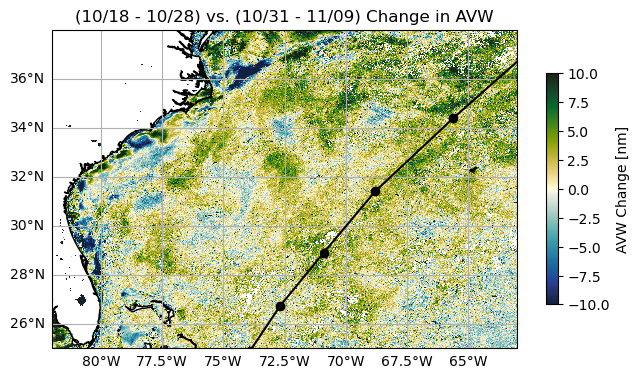

In [15]:
# compare the pre and post event data. first, mask both to only pixels where data is available before and after the hurricane
# then, mask each where it's values are greater or less than

# Calculate mean over pre and post event periods
pre_mean = data_avw.sel(time=slice(pre_tspan[0], pre_tspan[1])).mean("time")
post_mean = data_avw.sel(time=slice(post_tspan[0], post_tspan[1])).mean("time") 

# Create a mask where both datasets have valid values
masklong = ~np.isnan(post_mean) & ~np.isnan(pre_mean)

# Apply masks to datasets
# Calculate percent change over pre and post event periods during the post-event window
pre_mean_mask = pre_mean.where(masklong)
post_mean_mask = post_mean.where(masklong)
post_pct_change = post_mean_mask-pre_mean_mask

# Plot percent change during long post-event window
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_pct_change.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'AVW Change [nm]', 'shrink':0.5}, cmap=cmocean.cm.delta, extend = "neither", ax=ax, robust=True, vmin=-10, vmax=10)
ax.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.coastlines()
# Convert pre and post event times to readable format for title
pre_start_str = pd.to_datetime(pre_tspan[0]).strftime('%m/%d')
pre_end_str = pd.to_datetime(pre_tspan[1]).strftime('%m/%d')
post_start_str = pd.to_datetime(post_tspan[0]).strftime('%m/%d')
post_end_str = pd.to_datetime(post_tspan[1]).strftime('%m/%d')
ax.set_title(f'({pre_start_str} - {pre_end_str}) vs. ({post_start_str} - {post_end_str}) Change in AVW')

# Save figure
plt.savefig(f'{output_path}/ErinAVWChange.png', dpi=300, bbox_inches='tight')

### L2 chlorophyll-a data availability and time series of L2 chlorophyll-a data

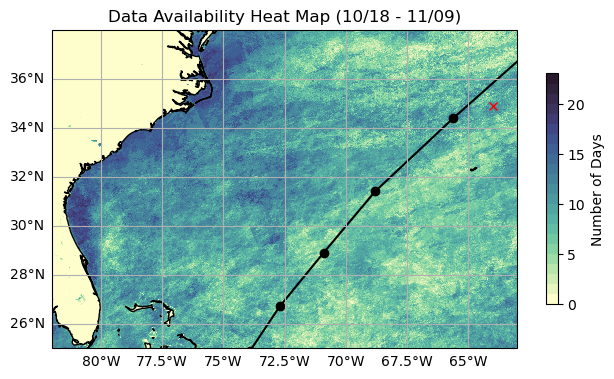

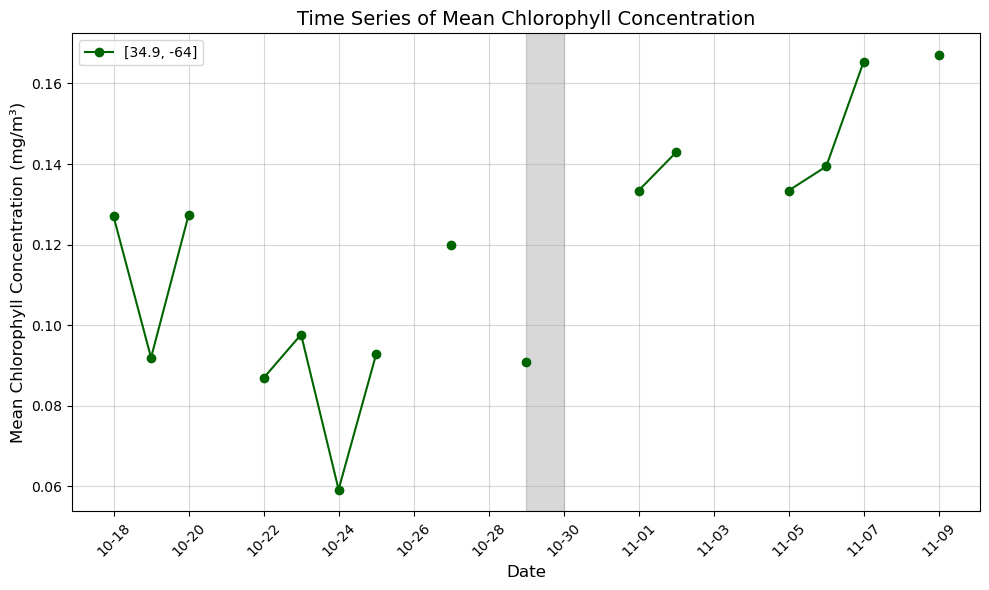

Exception ignored in: <function CachingFileManager.__del__ at 0x7fbca8b836a0>
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 258, in __del__
    self.close(needs_lock=False)
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 242, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2676, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2643, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2160, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fbca8b836a0>
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 258, in __del__
    self.close(needs_lock=False)
  

In [ ]:
## Chlorophyll-a time series at target point

# Data availability heat map
# Group the data by date and compute the mean for each group
data_chla_by_date = data_chla.groupby(data_chla['time'].dt.date).mean(dim='time')
# Count the number of non-NaN values across the time dimension
data_count = data_chla_by_date.count(dim='date')
# Get the total number of days in the 'date' dimension
total_days = len(data_chla_by_date['date'])

# Create a discrete colormap with `total_days` colors
discrete_cmap = ListedColormap(cmocean.cm.deep(np.linspace(0, 1, total_days)))

# Define boundaries for the colormap
boundaries = np.arange(0, total_days + 1)  # One boundary for each day

# Plot data availability heat map
fig,ax = plt.subplots(1, 1, figsize=(7.5, 6), subplot_kw={'projection': ccrs.PlateCarree()})
data_count.plot(
    x='longitude',
    y='latitude',
    cmap=discrete_cmap,  # Use the discrete colormap
    cbar_kwargs={
        'label': 'Number of Days',
        'spacing': 'proportional',
        'pad': 0.05,
        'shrink': 0.5
    },
    vmin=0,
    vmax=total_days,  # Set color bar range
    ax=ax
)
ax.plot(track['Longitude'], track['Latitude'], color='black', marker='o', transform=ccrs.PlateCarree(), label='Observed Track')
ax.plot(target_point[1], target_point[0], color='red', marker='x', transform=ccrs.PlateCarree(), label='Target Point')
ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
ax.coastlines()
start_str = pd.to_datetime(tspan[0]).strftime('%m/%d')
end_str = pd.to_datetime(tspan[1]).strftime('%m/%d')
ax.set_title(f'Data Availability Heat Map ({start_str} - {end_str})')
# Save figure
plt.savefig(f'{output_path}/_Chla_Data_Availability_Heat_Map.png', dpi=300, bbox_inches='tight')


# Extract chlorophyll-a time series at the target point
chla_timeseries = data_chla_by_date.sel(longitude=target_point[1], latitude=target_point[0], method='nearest')
# Determine the index of lat/lon to the target coordinate
target_point_idx = [data_chla_by_date.latitude.values.tolist().index(chla_timeseries.latitude.values), \
                  data_chla_by_date.longitude.values.tolist().index(chla_timeseries.longitude.values)]
# Select adjacent data
target_point_data = data_chla_by_date.isel(latitude=slice(target_point_idx[0]-3, target_point_idx[0]+4), \
                                  longitude=slice(target_point_idx[1]-3, target_point_idx[1]+4))# -2 +3 matts default
# Average over adjacent data 
target_point_data_mean = target_point_data.mean(dim=['latitude','longitude'])
# Extract the time values and chlorophyll concentrations for target_point_data_mean
time_values = target_point_data_mean['date'].values

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_values, target_point_data_mean.values, marker='o', linestyle='-', color=mcolors.CSS4_COLORS['darkgreen'], label=str(target_point))
# Format the x-axis to show dates
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean Chlorophyll Concentration (mg/m³)', fontsize=12)
ax.set_title('Time Series of Mean Chlorophyll Concentration', fontsize=14)
ax.grid(True, linestyle='-', alpha=0.5)
ax.legend()
# Set x-axis ticks to show every fourth day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.axvspan(np.datetime64(tp_tspan[0]), np.datetime64(tp_tspan[1]), 
                  color='gray', alpha=0.3)
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
# Save figure
plt.savefig(f'{output_path}/_Mean_Chlorophyll_Time_Series.png', dpi=300, bbox_inches='tight')
plt.show()



In [17]:
#MIXED LAYER DEPTH - from OEL-hosted HYCOM product

hycom_flist = download_MLT_hycom_files(tspan[0], tspan[1], data_path)
hycom_data = xr.open_mfdataset(hycom_flist, concat_dim='time', combine='nested')
hycom_data.coords['lon'] = (hycom_data.coords['lon'] + 180) % 360 - 180
hycom_data = hycom_data.sortby('lon')
hycom_data = hycom_data.sel(
    lat=slice(bbox[1],bbox[3]),
    lon=slice(bbox[0],bbox[2])
)

Downloaded: hycom_ESPC-D-V02.mlt.20251018.nc


Exception ignored in: <function CachingFileManager.__del__ at 0x7fef374534c0>
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 258, in __del__
    self.close(needs_lock=False)
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 242, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2676, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2643, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2160, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Downloaded: hycom_ESPC-D-V02.mlt.20251019.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251020.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251021.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251022.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251023.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251024.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251025.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251026.nc


Exception ignored in: <function CachingFileManager.__del__ at 0x7fdfafe6b920>
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 258, in __del__
    self.close(needs_lock=False)
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 242, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2676, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2643, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2160, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Downloaded: hycom_ESPC-D-V02.mlt.20251027.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251028.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251029.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251030.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251031.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251101.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251102.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251103.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251104.nc


Exception ignored in: <function CachingFileManager.__del__ at 0x7f4b5f68fba0>
Traceback (most recent call last):
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 258, in __del__
    self.close(needs_lock=False)
  File "/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 242, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2676, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2643, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2160, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Downloaded: hycom_ESPC-D-V02.mlt.20251105.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251106.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251107.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251108.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251109.nc


### Continuing on to more advance L3 and L4M data products: MOANA

In [29]:
dataset_MOANA = xr.open_mfdataset(paths_MOANA, preprocess=time_from_attr_L4MOANNA, combine='nested', concat_dim='time')
dataset_BGC = xr.open_mfdataset(paths_bgc_L3, preprocess=time_from_attr_L4MOANNA, combine='nested', concat_dim='time')
dataset_sst = xr.open_mfdataset(paths_sst, preprocess=time_from_attr_sst, combine='nested', concat_dim='time')



############ #chunk to conditionally account for a missing day of data
# #Add 2025-08-23 to dataset with NaNs since missing due to safehold
# gap_ds = dataset_MOANA.isel(time=-1).copy()
# # Set all data variables to NaN arrays (float dtype)
# for var in gap_ds.data_vars:
#     shape = gap_ds[var].shape
#     gap_ds[var] = (gap_ds[var].dims, np.full(shape, np.nan, dtype=float))
# gap_ds = gap_ds.assign_coords(time=[np.datetime64('2025-08-23')])
# dataset_MOANA = xr.concat([dataset_MOANA, gap_ds], dim='time')
# dataset_MOANA = dataset_MOANA.sortby('time')
###############


# Set SST time variables to midnight for consistency
dataset_sst = dataset_sst.assign_coords(time=dataset_sst['time'].dt.floor('D'))

# Get min/max values of L4 dataset within bounding box coordinates for later plotting
date_str = [str(date) for date in dataset_MOANA["time"].dt.date.values]

# Calculate 2-day coarsened mean of L3 & L4M data products
MOANA_mean_2 = dataset_MOANA.coarsen(time=2, boundary='trim').mean()
BGC_mean_2 = dataset_BGC.coarsen(time=2, boundary='trim').mean()

# Print time values to verify they are consistent between datasets
print(dataset_MOANA.time.values)
print(dataset_BGC.time.values)
print(dataset_sst.time.values)

['2025-10-18T00:00:00' '2025-10-19T00:00:00' '2025-10-20T00:00:00'
 '2025-10-21T00:00:00' '2025-10-22T00:00:00' '2025-10-23T00:00:00'
 '2025-10-24T00:00:00' '2025-10-25T00:00:00' '2025-10-26T00:00:00'
 '2025-10-27T00:00:00' '2025-10-28T00:00:00' '2025-10-29T00:00:00'
 '2025-10-30T00:00:00' '2025-10-31T00:00:00' '2025-11-01T00:00:00'
 '2025-11-02T00:00:00' '2025-11-03T00:00:00' '2025-11-04T00:00:00'
 '2025-11-05T00:00:00' '2025-11-06T00:00:00' '2025-11-07T00:00:00'
 '2025-11-08T00:00:00' '2025-11-09T00:00:00']
['2025-10-18T00:00:00' '2025-10-19T00:00:00' '2025-10-20T00:00:00'
 '2025-10-21T00:00:00' '2025-10-22T00:00:00' '2025-10-23T00:00:00'
 '2025-10-24T00:00:00' '2025-10-25T00:00:00' '2025-10-26T00:00:00'
 '2025-10-27T00:00:00' '2025-10-28T00:00:00' '2025-10-29T00:00:00'
 '2025-10-30T00:00:00' '2025-10-31T00:00:00' '2025-11-01T00:00:00'
 '2025-11-02T00:00:00' '2025-11-03T00:00:00' '2025-11-04T00:00:00'
 '2025-11-05T00:00:00' '2025-11-06T00:00:00' '2025-11-07T00:00:00'
 '2025-11-08T00:

### MOANA Analysis: Normalized to cell count maximum

/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/accounts/gtrolley/miniforge3/envs/hackweek/lib/python3.12/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


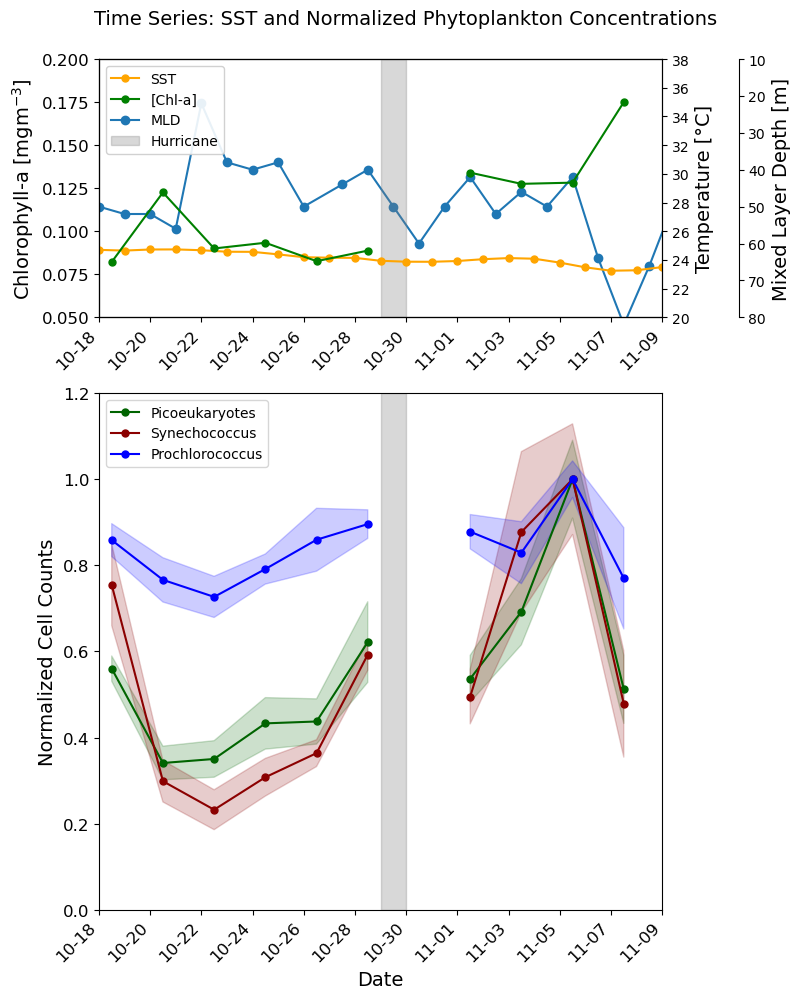

In [23]:
# Normalize phytoplankton functional type plots

# Find the nearest point to the target lat/lon coordinates
datanear =  MOANA_mean_2.sel(lat=target_point[0], lon=target_point[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
MOANA_tar_idx = [MOANA_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  MOANA_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
MOANA_data = MOANA_mean_2.isel(lat=slice(MOANA_tar_idx[0]-3, MOANA_tar_idx[0]+4), \
                                  lon=slice(MOANA_tar_idx[1]-3, MOANA_tar_idx[1]+4))
MOANA_std = dataset_MOANA.isel(lat=slice(MOANA_tar_idx[0]-3, MOANA_tar_idx[0]+4), \
                                  lon=slice(MOANA_tar_idx[1]-3, MOANA_tar_idx[1]+4))

# Calculate the mean of the selected adjacent data
MOANA_data = MOANA_data.mean(dim=['lat','lon']) #
MOANA_std = MOANA_std.std(dim=['lat','lon'])
MOANA_std = MOANA_std.coarsen(time=2, boundary='trim').mean()

###########################BGC Data Extraction########################
# Find the nearest point to the target lat/lon coordinates
datanear =  BGC_mean_2.sel(lat=target_point[0], lon=target_point[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
BGC_tar_idx = [BGC_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  BGC_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
BGC_data = BGC_mean_2.isel(lat=slice(BGC_tar_idx[0]-3, BGC_tar_idx[0]+4), \
                                  lon=slice(BGC_tar_idx[1]-3, BGC_tar_idx[1]+4))
BGC_std = dataset_BGC.isel(lat=slice(BGC_tar_idx[0]-3, BGC_tar_idx[0]+4), \
                                  lon=slice(BGC_tar_idx[1]-3, BGC_tar_idx[1]+4))

# Calculate the mean of the selected adjacent data
BGC_data = BGC_data.mean(dim=['lat','lon']) #
BGC_std = BGC_std.std(dim=['lat','lon'])
BGC_std = BGC_std.coarsen(time=2, boundary='trim').mean()

#############################SST Data Extraction############################
# Find the nearest point to the target lat/lon coordinates
sst_datanear = dataset_sst.sel(lat=target_point[0], lon=target_point[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
sst_tarcoords_idx = [dataset_sst.lat.values.tolist().index(sst_datanear.lat.values), \
                     dataset_sst.lon.values.tolist().index(sst_datanear.lon.values)]

# Select adjacent data (1x1 pixel grid)
tar1_data_sst = dataset_sst.isel(lat=slice(sst_tarcoords_idx[0], sst_tarcoords_idx[0]+1), \
                                 lon=slice(sst_tarcoords_idx[1], sst_tarcoords_idx[1]+1))

# Calculate the mean of the selected adjacent data
SST_data = tar1_data_sst.mean(dim=['lat','lon']) - 273.15  # Convert from Kelvin to Celsius

# Normalize phytoplankton data to their maximum values
pico_norm = MOANA_data['picoeuk_moana'] / MOANA_data['picoeuk_moana'].max()
sync_norm = MOANA_data['syncoccus_moana'] / MOANA_data['syncoccus_moana'].max()
proc_norm = MOANA_data['prococcus_moana'] / MOANA_data['prococcus_moana'].max()

# Normalize standard deviations proportionally
pico_std_norm = MOANA_std['picoeuk_moana'] / MOANA_data['picoeuk_moana'].max()
sync_std_norm = MOANA_std['syncoccus_moana'] / MOANA_data['syncoccus_moana'].max()
proc_std_norm = MOANA_std['prococcus_moana'] / MOANA_data['prococcus_moana'].max()

# Create 2x1 subplot layout with different heights
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(8, 10), 
                                         gridspec_kw={'height_ratios': [1, 2]})

# Extract time values
sst_time_values = SST_data['time'].values
moana_time_values = MOANA_data['time'].values
bgc_time_values = BGC_data['time'].values

# Create left y-axis for chlorophyll-a
ax_chl = ax_top
ax_chl.set_zorder(2)
ax_chl.plot(bgc_time_values, BGC_data['chlor_a'].values, 'o-',
            color=mcolors.CSS4_COLORS['green'], label="[Chl-a]", markersize=5)
# ax_chl.fill_between(bgc_time_values,
#                     (chl_norm - chl_std_norm).values,
#                     (chl_norm + chl_std_norm).values,
#                     color=mcolors.CSS4_COLORS['black'], alpha=0.2)
ax_chl.set_ylabel('Chlorophyll-a [mgm$^{-3}$]', fontsize=14, color=mcolors.CSS4_COLORS['black'])
ax_chl.tick_params(axis='y', labelcolor=mcolors.CSS4_COLORS['black'])
ax_chl.set_ylim(0.05, 0.2)


# Plot 1: SST (top panel)
ax_sst = ax_chl.twinx()
ax_sst.set_zorder(1)
ax_sst.plot(sst_time_values,
            SST_data['analysed_sst'].values,
            'o-',
            color=mcolors.CSS4_COLORS['orange'],
            label="SST",
            markersize=5)
ax_sst.axvspan(np.datetime64(tp_tspan[0]), np.datetime64(tp_tspan[1]), 
               color='gray', alpha=0.3, label='Hurricane')
ax_sst.set_ylabel('Temperature [°C]', fontsize=14)
ax_sst.set_ylim(20, 38)
#ax_top.set_ylim(np.floor(SST_data['analysed_sst'].values.min()), np.ceil(SST_data['analysed_sst'].values.max()))



# create 3rd y axis for MLD
mld_data = hycom_data.sel(lat=target_point[0], lon=target_point[1], method='nearest').mixed_layer_thickness.values
mld_time = hycom_data.sel(lat=target_point[0], lon=target_point[1], method='nearest').time.values

ax_mld = ax_chl.twinx()
ax_mld.set_zorder(0)
ax_mld.invert_yaxis()
#subset.sel(lat=target_point[0], lon = target_point[1], method='nearest').mixed_layer_thickness.plot(ax=ax_mld,)
ax_mld.plot(mld_time, mld_data, 'o-', label='MLD')
ax_mld.spines['right'].set_position(('outward', 55))  # Move right spine outward by 60 points
ax_mld.set_ylabel('Mixed Layer Depth [m]', fontsize=14)
ax_mld.set_ylim(80, 10)

# IMPORTANT: Set patch visibility to control what shows through
# This prevents lower axes from blocking higher ones
ax_chl.patch.set_visible(False)   # Keep background visible for bottom layer
ax_sst.patch.set_visible(False)  # Make background transparent for middle layer
ax_mld.patch.set_visible(True)  # Make background transparent for top layer

# Combine legends from both axes
handles_sst, labels_sst = ax_sst.get_legend_handles_labels()
handles_chl, labels_chl = ax_chl.get_legend_handles_labels()
handles_mld, labels_mld = ax_mld.get_legend_handles_labels()


ax_chl.legend(handles_sst[0:1] + handles_chl + handles_mld + handles_sst[1:2],
              labels_sst[0:1] + labels_chl + labels_mld + labels_sst[1:2],
              frameon=True, framealpha=0.9)#bbox_to_anchor=(0.98, 0.94)


# Bottom panel: All normalized phytoplankton on left, chlorophyll on right
# Plot all three phytoplankton on left axis
ax_bottom.plot(moana_time_values, pico_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['darkgreen'], label="Picoeukaryotes", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (pico_norm - pico_std_norm).values,
                       (pico_norm + pico_std_norm).values,
                       color=mcolors.CSS4_COLORS['darkgreen'], alpha=0.2)

ax_bottom.plot(moana_time_values, sync_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['darkred'], label="Synechococcus", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (sync_norm - sync_std_norm).values,
                       (sync_norm + sync_std_norm).values,
                       color=mcolors.CSS4_COLORS['darkred'], alpha=0.2)

ax_bottom.plot(moana_time_values, proc_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['blue'], label="Prochlorococcus", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (proc_norm - proc_std_norm).values,
                       (proc_norm + proc_std_norm).values,
                       color=mcolors.CSS4_COLORS['blue'], alpha=0.2)

ax_bottom.set_ylabel('Normalized Cell Counts', fontsize=14)
ax_bottom.set_ylim(0, 1.2)


# Add event shading
ax_bottom.axvspan(np.datetime64(tp_tspan[0]), np.datetime64(tp_tspan[1]), 
                  color='gray', alpha=0.3)

# Labels and formatting
ax_bottom.set_xlabel('Date', fontsize=14)

# Combine legends from both axes
handles_phyto, labels_phyto = ax_bottom.get_legend_handles_labels()
handles_chl, labels_chl = ax_chl.get_legend_handles_labels()

ax_bottom.legend(handles_phyto,
                 labels_phyto,
                 loc='upper left', frameon=True, framealpha=0.8)

# Format x-axis for both subplots
for axis in [ax_top, ax_bottom]:
    axis.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axis.xaxis.set_tick_params(labelsize=12)
    axis.yaxis.set_tick_params(labelsize=12)
    axis.set_xlim(np.datetime64(tspan[0]), np.datetime64(tspan[1]))
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Time Series: SST and Normalized Phytoplankton Concentrations', fontsize=14, y=0.995)
plt.tight_layout()

# Save figure
plt.savefig(f'{output_path}/MOANA_SST_CHL_TimeSeries_postnorm.png', dpi=300, bbox_inches='tight')

### MOANA Analysis: Normalized to cell counts pre-event

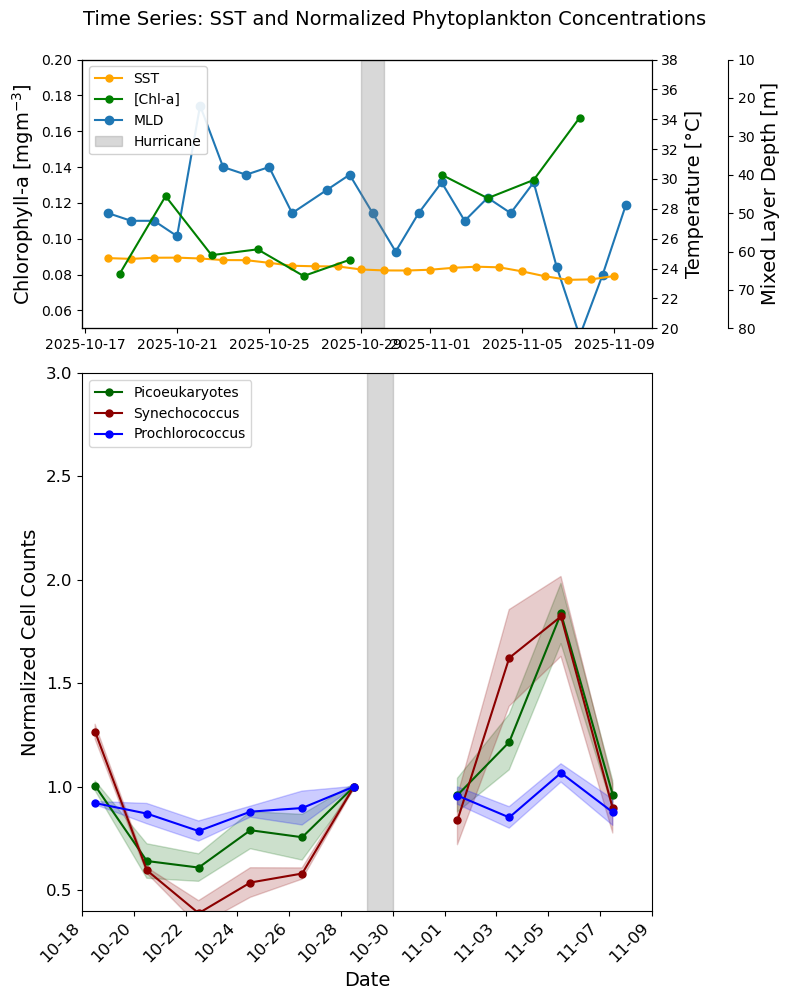

In [30]:
# Normalize phytoplankton functional type plots to day before event

# Find the nearest point to the target lat/lon coordinates
datanear =  MOANA_mean_2.sel(lat=target_point[0], lon=target_point[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
MOANA_tar_idx = [MOANA_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  MOANA_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
MOANA_data = MOANA_mean_2.isel(lat=slice(MOANA_tar_idx[0]-2, MOANA_tar_idx[0]+3), \
                                  lon=slice(MOANA_tar_idx[1]-2, MOANA_tar_idx[1]+3))
MOANA_std = dataset_MOANA.isel(lat=slice(MOANA_tar_idx[0]-2, MOANA_tar_idx[0]+3), \
                                  lon=slice(MOANA_tar_idx[1]-2, MOANA_tar_idx[1]+3))

# Calculate the mean of the selected adjacent data
MOANA_data = MOANA_data.mean(dim=['lat','lon']) #
MOANA_std = MOANA_std.std(dim=['lat','lon'])
MOANA_std = MOANA_std.coarsen(time=2, boundary='trim').mean()

###########################BGC Data Extraction########################
# Find the nearest point to the target lat/lon coordinates
datanear =  BGC_mean_2.sel(lat=target_point[0], lon=target_point[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
BGC_tar_idx = [BGC_mean_2.lat.values.tolist().index(datanear.lat.values), \
                  BGC_mean_2.lon.values.tolist().index(datanear.lon.values)]
# Select adjacent data
BGC_data = BGC_mean_2.isel(lat=slice(BGC_tar_idx[0]-2, BGC_tar_idx[0]+3), \
                                  lon=slice(BGC_tar_idx[1]-2, BGC_tar_idx[1]+3))
BGC_std = dataset_BGC.isel(lat=slice(BGC_tar_idx[0]-2, BGC_tar_idx[0]+3), \
                                  lon=slice(BGC_tar_idx[1]-2, BGC_tar_idx[1]+3))

# Calculate the mean of the selected adjacent data
BGC_data = BGC_data.mean(dim=['lat','lon']) #
BGC_std = BGC_std.std(dim=['lat','lon'])
BGC_std = BGC_std.coarsen(time=2, boundary='trim').mean()

#############################SST Data Extraction############################
# Find the nearest point to the target lat/lon coordinates
sst_datanear = dataset_sst.sel(lat=target_point[0], lon=target_point[1], method='nearest')

# Determine the index of lat/lon to the target coordinate
sst_tarcoords_idx = [dataset_sst.lat.values.tolist().index(sst_datanear.lat.values), \
                     dataset_sst.lon.values.tolist().index(sst_datanear.lon.values)]

# Select adjacent data (1x1 pixel grid)
tar1_data_sst = dataset_sst.isel(lat=slice(sst_tarcoords_idx[0], sst_tarcoords_idx[0]+1), \
                                 lon=slice(sst_tarcoords_idx[1], sst_tarcoords_idx[1]+1))

# Calculate the mean of the selected adjacent data
SST_data = tar1_data_sst.mean(dim=['lat','lon']) - 273.15  # Convert from Kelvin to Celsius

# Normalize phytoplankton data to the day before the event
pico_norm = MOANA_data['picoeuk_moana'] / MOANA_data['picoeuk_moana'].sel(time=day_before,method='nearest')
sync_norm = MOANA_data['syncoccus_moana'] / MOANA_data['syncoccus_moana'].sel(time=day_before,method='nearest')
proc_norm = MOANA_data['prococcus_moana'] / MOANA_data['prococcus_moana'].sel(time=day_before,method='nearest')

# Normalize standard deviations proportionally
pico_std_norm = MOANA_std['picoeuk_moana'] / MOANA_data['picoeuk_moana'].sel(time=day_before,method='nearest')#MOANA_data['picoeuk_moana'].max()
sync_std_norm = MOANA_std['syncoccus_moana'] / MOANA_data['syncoccus_moana'].sel(time=day_before,method='nearest')#MOANA_data['syncoccus_moana'].max()
proc_std_norm = MOANA_std['prococcus_moana'] / MOANA_data['prococcus_moana'].sel(time=day_before,method='nearest')#MOANA_data['prococcus_moana'].max()

# Create 2x1 subplot layout with different heights
fig, (ax_chl, ax_bottom) = plt.subplots(2, 1, figsize=(8, 10), 
                                         gridspec_kw={'height_ratios': [1, 2]})

# Extract time values
sst_time_values = SST_data['time'].values
moana_time_values = MOANA_data['time'].values
bgc_time_values = BGC_data['time'].values

# Create left y-axis for chlorophyll-a
ax_chl.set_zorder(2)
ax_chl.plot(bgc_time_values, BGC_data['chlor_a'].values, 'o-',
            color=mcolors.CSS4_COLORS['green'], label="[Chl-a]", markersize=5)
# ax_chl.fill_between(bgc_time_values,
#                     (chl_norm - chl_std_norm).values,
#                     (chl_norm + chl_std_norm).values,
#                     color=mcolors.CSS4_COLORS['black'], alpha=0.2)
ax_chl.set_ylabel('Chlorophyll-a [mgm$^{-3}$]', fontsize=14, color=mcolors.CSS4_COLORS['black'])
ax_chl.tick_params(axis='y', labelcolor=mcolors.CSS4_COLORS['black'])
ax_chl.set_ylim(0.05, 0.2)


# Plot 1: SST (top panel)
ax_sst = ax_chl.twinx()
ax_sst.set_zorder(1)
ax_sst.plot(sst_time_values,
            SST_data['analysed_sst'].values,
            'o-',
            color=mcolors.CSS4_COLORS['orange'],
            label="SST",
            markersize=5)
ax_sst.axvspan(np.datetime64(tp_tspan[0]), np.datetime64(tp_tspan[1]), 
               color='gray', alpha=0.3, label='Hurricane')
ax_sst.set_ylabel('Temperature [°C]', fontsize=14)
ax_sst.set_ylim(20, 38)
#ax_top.set_ylim(np.floor(SST_data['analysed_sst'].values.min()), np.ceil(SST_data['analysed_sst'].values.max()))



# create 3rd y axis for MLD
mld_data = hycom_data.sel(lat=target_point[0], lon=target_point[1], method='nearest').mixed_layer_thickness.values
mld_time = hycom_data.sel(lat=target_point[0], lon=target_point[1], method='nearest').time.values

ax_mld = ax_chl.twinx()
ax_mld.set_zorder(0)
ax_mld.invert_yaxis()
#subset.sel(lat=target_point[0], lon = target_point[1], method='nearest').mixed_layer_thickness.plot(ax=ax_mld,)
ax_mld.plot(mld_time, mld_data, 'o-', label='MLD')
ax_mld.spines['right'].set_position(('outward', 55))  # Move right spine outward by 60 points
ax_mld.set_ylabel('Mixed Layer Depth [m]', fontsize=14)
ax_mld.set_ylim(80, 10)

# IMPORTANT: Set patch visibility to control what shows through
# This prevents lower axes from blocking higher ones
ax_chl.patch.set_visible(False)   # Keep background visible for bottom layer
ax_sst.patch.set_visible(False)  # Make background transparent for middle layer
ax_mld.patch.set_visible(True)  # Make background transparent for top layer

# Combine legends from both axes
handles_sst, labels_sst = ax_sst.get_legend_handles_labels()
handles_chl, labels_chl = ax_chl.get_legend_handles_labels()
handles_mld, labels_mld = ax_mld.get_legend_handles_labels()


ax_chl.legend(handles_sst[0:1] + handles_chl + handles_mld + handles_sst[1:2],
              labels_sst[0:1] + labels_chl + labels_mld + labels_sst[1:2],
            frameon=True, framealpha=0.9)


# Bottom panel: All normalized phytoplankton on left, chlorophyll on right
# Plot all three phytoplankton on left axis
ax_bottom.plot(moana_time_values, pico_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['darkgreen'], label="Picoeukaryotes", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (pico_norm - pico_std_norm).values,
                       (pico_norm + pico_std_norm).values,
                       color=mcolors.CSS4_COLORS['darkgreen'], alpha=0.2)

ax_bottom.plot(moana_time_values, sync_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['darkred'], label="Synechococcus", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (sync_norm - sync_std_norm).values,
                       (sync_norm + sync_std_norm).values,
                       color=mcolors.CSS4_COLORS['darkred'], alpha=0.2)

ax_bottom.plot(moana_time_values, proc_norm.values, 'o-',
               color=mcolors.CSS4_COLORS['blue'], label="Prochlorococcus", markersize=5)
ax_bottom.fill_between(moana_time_values,
                       (proc_norm - proc_std_norm).values,
                       (proc_norm + proc_std_norm).values,
                       color=mcolors.CSS4_COLORS['blue'], alpha=0.2)

ax_bottom.set_ylabel('Normalized Cell Counts', fontsize=14)
ax_bottom.set_ylim(0.4, 3)


# Add event shading
ax_bottom.axvspan(np.datetime64(tp_tspan[0]), np.datetime64(tp_tspan[1]), 
                  color='gray', alpha=0.3)

# Labels and formatting
ax_bottom.set_xlabel('Date', fontsize=14)

# Combine legends from both axes
handles_phyto, labels_phyto = ax_bottom.get_legend_handles_labels()
handles_chl, labels_chl = ax_chl.get_legend_handles_labels()

ax_bottom.legend(handles_phyto,
                 labels_phyto,
                 loc='upper left', frameon=True, framealpha=0.8)

# Format x-axis for both subplots
for axis in [ax_top, ax_bottom]:
    axis.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axis.xaxis.set_tick_params(labelsize=12)
    axis.yaxis.set_tick_params(labelsize=12)
    axis.set_xlim(np.datetime64(tspan[0]), np.datetime64(tspan[1]))
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Time Series: SST and Normalized Phytoplankton Concentrations', fontsize=14, y=0.995)
plt.tight_layout()

# Save figure
plt.savefig(f'{output_path}/MOANA_SST_CHL_TimeSeries_prenorm.png', dpi=300, bbox_inches='tight')